# NEOFC - Positive-control in resting-state network probability maps

In [12]:
from pathlib import Path 
import pandas as pd 
import numpy as np 
import pickle
import gzip 
import seaborn as sn
from PIL import Image
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn.objects as so
import pickle
from scipy.stats import rankdata

from utils import load_pickled_mapconn, load_neofc_stats, get_ref_data, get_stats, calc_retest, get_dist_mat
from mapconn import MapConn, MapConnNull, MapConnInv
from mapconn.plot import plot_mapconn_curves


# working directory
wd = Path.cwd() 
print(wd)

# general vars
from utils import (REF_GROUPS, REF_NAMES_RSN, REF_GROUPS_COLORS, REF_GROUPS_PET, REF_NAMES_PET,
                   PARC_DEFAULT, PARCS_ALL, PARCS_CX, REF_COLORS_BY_MAP,
                   MEASURES_ALL, MEASURE_DEFAULT, MEASURES_NICE)

/Users/llotter/projects/mapfc


##  Data

### MapConn objects

In [13]:
mapconn_ya_mri_rsn = load_pickled_mapconn("hcp_ya_mri", parcs=PARCS_CX, dset="rsn")

Loading pickled MapConn objects: 100%|██████████| 3/3 [00:07<00:00,  2.34s/it]


### MapConn (NEOFC) results

In [14]:
# RSN
neofc_ya_mri_posctrl_groupstats, neofc_ya_mri_posctrl_indivstats = load_neofc_stats("hcp_ya_mri", PARCS_CX, dset="rsn")
#display(neofc_ya_mri_posctrl_groupstats, neofc_ya_mri_posctrl_indivstats)

Loading group stats: /Users/llotter/projects/mapfc/results/neofc/hcp_ya_mri/parc-..._dset-rsn_stat-..._group.csv.gz
Loading individual stats: /Users/llotter/projects/mapfc/results/neofc/hcp_ya_mri/parc-..._dset-rsn_stat-..._individual.csv.gz


### "Positive-Control": Resting-state network reference maps

In [15]:
data_ref = get_ref_data("rsn", parcs=PARCS_CX)
color = REF_GROUPS_COLORS[0]

data_ref["Schaefer200"]

Loading parcellated rsn data, standardized=True, null=False


,hemi-L_div-Vis_lab-1,hemi-L_div-Vis_lab-2,hemi-L_div-Vis_lab-3,hemi-L_div-Vis_lab-4,hemi-L_div-Vis_lab-5,hemi-L_div-Vis_lab-6,hemi-L_div-Vis_lab-7,hemi-L_div-Vis_lab-8,hemi-L_div-Vis_lab-9,hemi-L_div-Vis_lab-10,...,hemi-R_div-Default_lab-PFCm+1,hemi-R_div-Default_lab-PFCm+2,hemi-R_div-Default_lab-PFCm+3,hemi-R_div-Default_lab-PFCm+4,hemi-R_div-Default_lab-PFCm+5,hemi-R_div-Default_lab-PFCm+6,hemi-R_div-Default_lab-PFCm+7,hemi-R_div-Default_lab-PCC+1,hemi-R_div-Default_lab-PCC+2,hemi-R_div-Default_lab-PCC+3
map,,,,,,,,,,,,,,,,,,,,,
Auditory,-0.159284,-0.230507,-0.224921,0.149800,-0.255772,-0.031449,-0.535575,0.575410,0.024890,0.161907,...,-0.614900,-0.702527,-0.406459,-1.140895,-1.224636,-1.245569,-1.475934,-0.646889,-1.266246,-1.253240
Cingulo-Opercular,-0.217488,-0.219558,-0.073410,0.116717,-0.331638,-0.558202,-0.305104,-0.033958,-0.241860,0.053739,...,-1.557044,-0.706140,0.929363,-1.589205,-1.822869,-1.102896,-1.879880,-1.540963,-2.138948,-1.027929
Dorsal Attention,-0.018557,-0.066207,1.836998,-0.351941,-0.465445,-0.869025,-0.617771,0.550149,-0.502467,-0.648867,...,-1.262135,-1.833661,-1.167934,-1.827677,-1.716968,-0.862358,-1.237097,-1.043661,-1.767560,-0.407248
Default Mode,-0.430093,-0.447888,-0.848508,-0.783497,0.073128,0.179554,-0.284576,-0.307272,-0.256012,-0.476781,...,1.707012,1.960741,0.698147,2.324282,2.121116,1.638298,2.054389,1.433370,2.624936,1.356028
Frontoparietal,-0.706892,-0.426404,0.351052,-0.901872,-0.140259,-1.158508,-0.320732,-0.828056,-0.705014,-0.989451,...,-0.872988,-0.936924,-0.599632,-0.666902,-0.097375,0.582992,0.768836,-0.804125,-0.404416,0.324543
Medial Parietal,0.037830,-0.384946,-0.870194,0.306039,-0.443408,0.389706,0.222969,-0.971828,-0.535347,0.588409,...,-0.222882,1.157008,1.677952,-0.292977,-0.520357,0.743636,0.183443,1.872499,2.357657,2.806996
Occipital Parietal,1.718853,-0.336745,0.229757,0.503515,-0.887372,2.426857,-0.113637,0.119775,-0.820350,1.083084,...,0.863955,0.386058,-0.284160,-0.018877,-0.378845,1.206126,0.985294,4.194440,2.025910,2.289128
Dorsal Somatomotor,-0.379113,-0.217469,0.089536,-0.085427,-0.050478,-0.145792,-0.389249,0.385504,-0.041318,-0.235408,...,-0.296359,-0.751176,-0.620600,-0.945232,-1.115388,-1.222819,-1.406883,-0.590815,-0.962956,-1.150499
Lateral Somatomotor,-0.231892,-0.011454,0.121977,-0.047178,-0.037767,-0.180066,-0.404520,0.335770,0.125582,-0.245149,...,-0.489213,-0.925918,-0.669620,-1.048481,-1.102763,-1.248952,-1.388388,-0.702871,-1.108029,-1.290136


## Positive-Control

### Calculate test-retest consistency

In [16]:
neofc_ya_mri_posctrl_retest = calc_retest(
    neofc_ya_mri_posctrl_indivstats.loc[:, :, :, :, :, :, "val", :],
    save_path=wd / "results" / "neofc" / "hcp_ya_mri" / "parcs-CX_dset-rsn_retest.csv",
    overwrite=False
)

print("Test-retest consistency (example for visual network):")
display(neofc_ya_mri_posctrl_retest.loc[:,:,:,:,:, "Visual"].loc[:, (slice(None), ["ICC", "WCV"])])

100%|██████████| 12/12 [00:00<00:00, 26.24it/s]


Test-retest consistency (example for visual network):


ICC(2,1)  ICC(2,k)  ICC(3,1)  \
                                                     ICC       ICC       ICC   
parc        measure connections metric   stat                                  
Schaefer100 pearson all         original auc    0.579953  0.734140  0.579832   
                                inverted auc    0.621423  0.766516  0.622824   
                                original poly2  0.600090  0.750071  0.603124   
                                inverted poly2  0.610940  0.758489  0.643052   
Schaefer200 pearson all         original auc    0.569401  0.725629  0.571318   
                                inverted auc    0.621178  0.766329  0.621978   
                                original poly2  0.608989  0.756983  0.612709   
                                inverted poly2  0.627443  0.771078  0.643733   
Schaefer400 pearson all         original auc    0.580783  0.734805  0.581721   
                                inverted auc    0.608675  0.756741  0.609518   
                                original poly2  0.641447  0.781563  0.646041   
                                inverted poly2  0.574885  0.730066  0.589037   

                                                ICC(3,k)        CV  
                                                     ICC       WCV  
parc        measure connections metric   stat                       
Schaefer100 pearson all         original auc    0.734043  0.113590  
                                inverted auc    0.767580  0.165438  
                                original poly2  0.752436  0.165914  
                                inverted poly2  0.782753  0.166657  
Schaefer200 pearson all         original auc    0.727184  0.119001  
                                inverted auc    0.766938  0.143161  
                                original poly2  0.759851  0.165912  
                                inverted poly2  0.783257  0.130810  
Schaefer400 pearson all         original auc    0.735555  0.120778  
                                inverted auc    0.757392  0.140447  
                                original poly2  0.784963  0.176018  
                                inverted poly2  0.741376  0.123862

### Plot curves

In [17]:
def plot_curves(parc, measure, connections, save_path=None, stat="auc",
                maps=REF_NAMES_RSN, fig=None, axes=None):
    
    # mapconn instances
    mc1 = mapconn_ya_mri_rsn[parc][measure][connections]["1"]
    mc2 = mapconn_ya_mri_rsn[parc][measure][connections]["2"]
    
    # plot settings
    if fig is None or axes is None:
        fig, axes = plt.subplots(4, 3, figsize=(13, 12), sharex=True, sharey=True)
    axes_curves = [ax.inset_axes((0, 0, 0.83, 1)) for ax in axes.ravel()]
    axes_auc = [ax.inset_axes((0.85, 0, 0.15, 1)) for ax in axes.ravel()]
    axes_brain = [ax.inset_axes((0, 1, 1, 0.3), zorder=-100) for ax in axes.ravel()]
        
    # original mapconn curves
    fig, axes = plot_mapconn_curves(
        curves_obs=mc1.get_curves(maps=maps), 
        colors=color,
        n_cols=3,
        legend=False,
        titles=None,
        fig=fig,
        axes=axes,
        inset_axes=axes_curves,
        plot_kws={"label": "Original FC mean (90% PI)", "zorder_mean": 1000, "alpha": 0.8},
    )
    
    # inverted mapconn curves
    fig, axes = plot_mapconn_curves(
        curves_obs=mc1.get_inverted_curves(maps=maps), 
        curves_null=mc1.get_null_curves_dist(maps=maps),
        colors="tab:red",
        n_cols=3,
        legend=False,
        titles=None,
        fig=fig,
        axes=axes,
        inset_axes=axes_curves,
        plot_kws={"label": "Inverted FC mean (90% PI)", "plot_individual": False, "zorder_mean": 900, "alpha": 0.8},
    ) 

    # stats
    for m, ax in zip(maps, axes_curves):
        obs_p = neofc_ya_mri_posctrl_groupstats.loc[(parc, measure, connections, 1, "original", stat, "p"), m]
        obs_pmeff = neofc_ya_mri_posctrl_groupstats.loc[(parc, measure, connections, 1, "original", stat, "pmeff"), m]
        inv_p = neofc_ya_mri_posctrl_groupstats.loc[(parc, measure, connections, 1, "inverted", stat, "p"), m]
        inv_pmeff = neofc_ya_mri_posctrl_groupstats.loc[(parc, measure, connections, 1, "inverted", stat, "pmeff"), m]
        cv = neofc_ya_mri_posctrl_retest.loc[(parc, measure, connections, "original", stat, m), ('CV', 'WCV')]
        icc = neofc_ya_mri_posctrl_retest.loc[(parc, measure, connections, "original", stat, m), ('ICC(2,k)', 'ICC')]
        
        ax.annotate(
            f"$p_{{AUC\t{{+}}}} = {obs_p:.3f}$\n"
            f"$p_{{AUC\t{{-}}}} = {inv_p:.3f}$\n" 
            f"$ICC(2,k)_{{AUC\t{{+}}}} = {icc:.2f}$\n"
            f"$WCV_{{AUC\t{{+}}}} = {cv:.2f}$",
            xy=(0.05, 0.95),
            xycoords="axes fraction",
            ha="left",
            va="top",
            fontsize=10,
        )
        
        # highlight
        ax_sig = ax.inset_axes((0, 0, 1, 1))
        ax_sig.set_axis_off()
        ax_sig.set_xlim(0, 1)
        ax_sig.set_ylim(0, 1)
        if obs_p < 0.05:
            ax_sig.plot(0.9, 0.9, marker="$★$" if obs_pmeff < 0.05 else "$☆$", markersize=9, color=color)
        if inv_p < 0.05:
            ax_sig.plot(0.9, 0.8, marker="$★$" if inv_pmeff < 0.05 else "$☆$", markersize=9, color="tab:red")
    
    # auc
    auc_null = pd.concat([
        (
            mc.get_null_stats_dist(stats=stat) 
            .loc[["1%", "10%", "25%", "50%", "75%", "90%", "99%"]] 
            .reset_index(names=["p"]).melt(id_vars=["p"], value_name=stat)
            .assign(run=run)
        )
        for run, mc in enumerate([mc1, mc2], start=1)
    ])
    for m, ax in zip(maps, axes_auc):
        (
            so.Plot(
                data=(
                    neofc_ya_mri_posctrl_indivstats
                    .loc[(parc, measure, connections, slice(None), ["original", "inverted"], stat, "val", slice(None)), m]
                    .reset_index()
                ),
                x="run", 
                y=m, 
                color="metric"
            ) 
            .add(so.Line(linewidth=0.5, alpha=0.1), so.Jitter(0.5), group="id", legend=False) 
            .add(so.Range(alpha=0.8), so.Est(errorbar=("pi", 90)), legend=False)
            .add(so.Dot(alpha=0.8), so.Agg(), legend=False)
            .add(so.Line(alpha=0.8), so.Agg(), legend=False)
            .scale(color=so.Nominal([color, "tab:red"]))
            .on(ax)
            .plot()
        )
        ax.plot(
            [1, 2],
            auc_null.loc[(auc_null.p=="50%") & (auc_null["map"]==m), stat],
            color="0.3",
            linewidth=2,
            alpha=1,
        )
        for p1, p2, c in [("1%", "99%", "0.9"), ("10%", "90%", "0.8"), ("25%", "75%", "0.7")]:
            ax.fill_between(
                [1, 2],
                auc_null.loc[(auc_null.p==p1) & (auc_null["map"]==m), stat],
                auc_null.loc[(auc_null.p==p2) & (auc_null["map"]==m), stat],
                color=c,
                alpha=1,
                zorder=-1000  
            )
        ax.yaxis.set_label_position("right")
        ax.yaxis.tick_right()
        
    # layout
    for m, ax_main, ax_curve, ax_auc in zip(maps, axes.ravel(), axes_curves, axes_auc):
        ax_main.set_axis_off()
        # title
        ax_main.set_title(m, weight="semibold", color=color)
        # limits
        ax_curve.set_ylim(min([ax.get_ylim()[0] for ax in axes_curves]), 
                        max([ax.get_ylim()[1] for ax in axes_curves]))
        ax_auc.set_ylim(min([ax.get_ylim()[0] for ax in axes_auc]), 
                        max([ax.get_ylim()[1] for ax in axes_auc]))
        # labels
        # first column
        if ax_main.get_subplotspec().is_first_col():
            ax_curve.set_ylabel("FC")
        else:
            ax_curve.set_ylabel("") 
            #ax_curve.set_yticks(ax_curve.get_yticks(), labels=[])
        # last column
        if ax_main.get_subplotspec().is_last_col() and ax_main.get_subplotspec().is_first_row():
            ax_auc.set_ylabel("AUC", rotation=-90, va="bottom")
            handles, labels = ax_curve.get_legend_handles_labels()
            handles += [(plt.Line2D([0], [0], color=color, marker="$☆$", linestyle="None"),
                         plt.Line2D([0], [0], color=color, marker="$★$", linestyle="None")),
                        (plt.Line2D([0], [0], color="tab:red", marker="$☆$", linestyle="None"),
                         plt.Line2D([0], [0], color="tab:red", marker="$★$", linestyle="None"))]
            labels += ["$AUC\t{+}:\ p\ /\ p_{Meff} < 0.05$", "$AUC\t{-}:\ p\ /\ p_{Meff} < 0.05$"]
            ax_main.legend(handles, labels, loc="center left", bbox_to_anchor=(1.3, 0.5),
                           handler_map={tuple: mpl.legend_handler.HandlerTuple(ndivide=None)},)
        if not ax_main.get_subplotspec().is_last_col():
            ax_auc.set_ylabel("")
            #ax_auc.set_yticks(ax_auc.get_yticks(), labels=[])
        # last row
        if ax_main.get_subplotspec().is_last_row():
            ax_curve.set_xlabel("Percentile")
            ax_curve.set_xticks([0, 20, 40, 60, 80])
            ax_auc.set_xlabel("Run")
        else:
            ax_curve.set_xticks([0, 20, 40, 60, 80], labels=[])
            ax_auc.set_xticks([1, 2], labels=[])
            ax_auc.set_xlabel("")
    
    # brain
    for ax, m in zip(axes_brain, maps):
        try:
            ax.imshow(Image.open(wd / "plots" / "reference" / f"reference-{m.replace(' ', '').replace('-', '')}_parc-{parc}.png"))
        except FileNotFoundError:
            pass
        ax.set_axis_off()
    
    # save
    fig.tight_layout(w_pad=3)
    
    if save_path is None:
        plt.show()
    else:
        fig.savefig(save_path, bbox_inches="tight", dpi=400)

Schaefer100
Schaefer200


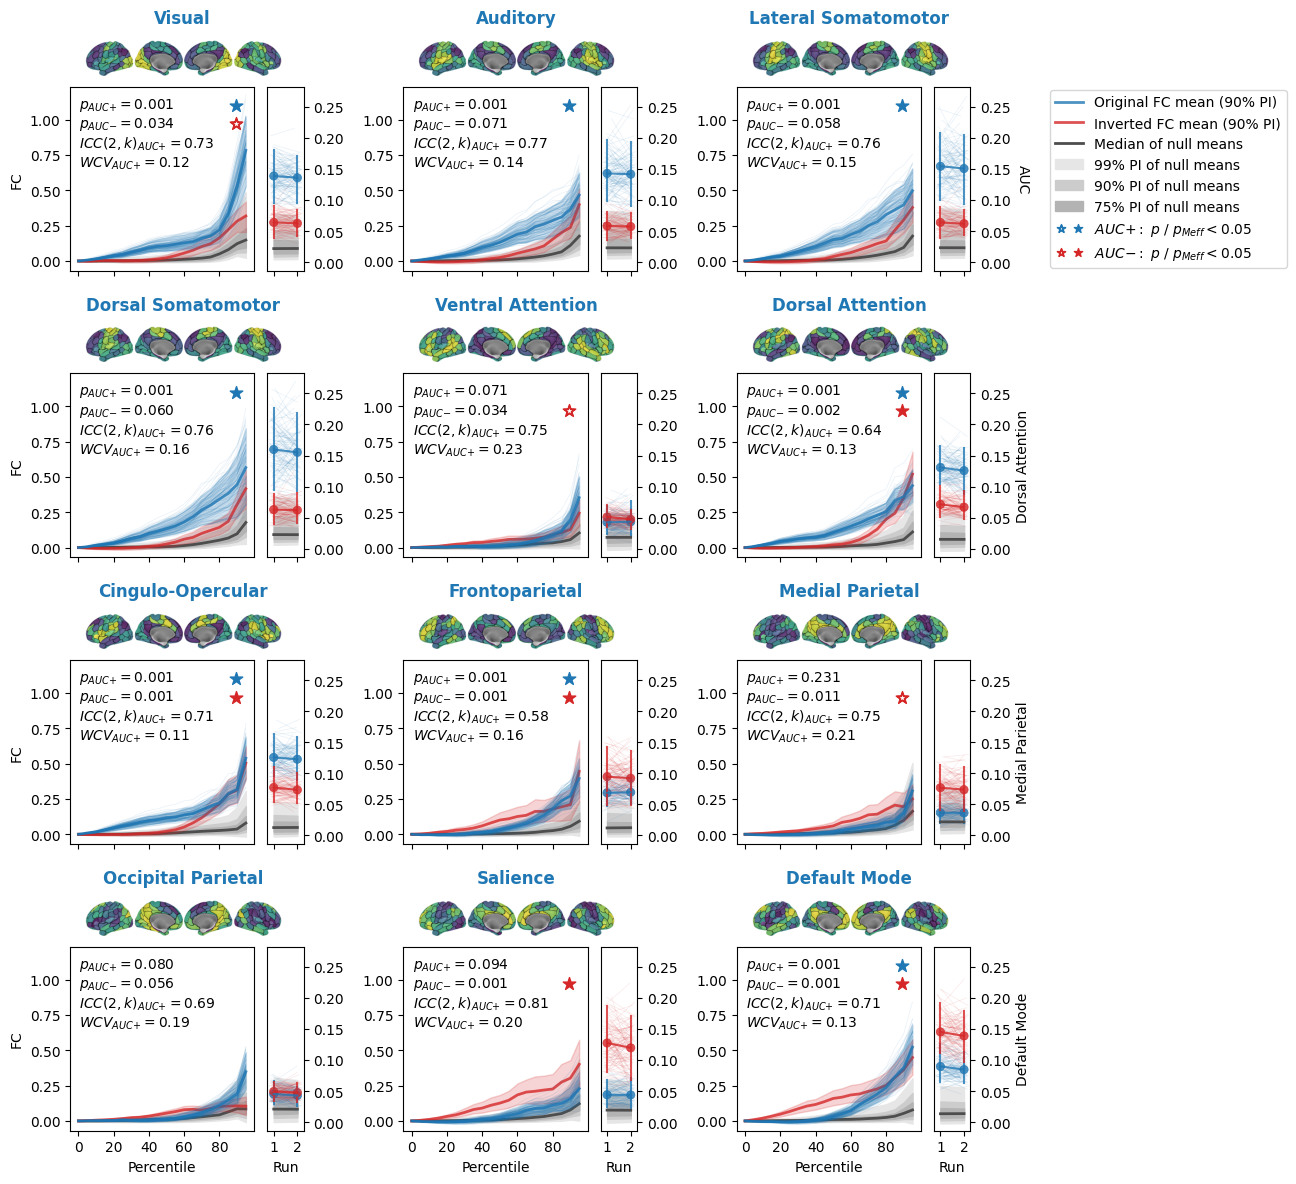

Schaefer400


In [18]:
measure = "pearson"
for parc in PARCS_CX:
    print(parc)
    plot_curves(parc, measure, "all", save_path=wd / "plots" / "evaluate" / f"posctrl_parc-{parc}_measure-{measure}.pdf")
    if parc in PARC_DEFAULT:
        plt.show()
    else:
        plt.close()

### Plot selected curves

/var/folders/6n/h4150p8d5gz5kbnqv5_406940000gp/T/ipykernel_26027/2408938210.py:172: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(w_pad=3)
/var/folders/6n/h4150p8d5gz5kbnqv5_406940000gp/T/ipykernel_26027/1381766585.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().set_visible(False)


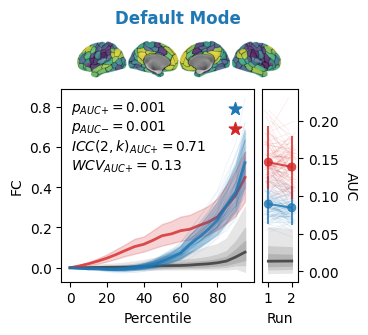

In [19]:
parc = "Schaefer200"
measure = "pearson"

fig, ax = plt.subplots(1, 1, figsize=(3.1, 2.5), sharex=True, sharey=True)
plot_curves(
    parc, measure, "all",
    save_path=wd / "plots" / "evaluate" / f"posctrlsel_parc-{parc}_measure-{measure}.svg",
    maps=["Default Mode"],
    fig=fig,
    axes=np.array([ax])
)
ax.legend().set_visible(False)
# leg = ax.axes.get_children()[-2] #.get_legend_handles_labels()
# ax.legend(leg.legend_handles, [t.get_text() for t in leg.texts], loc="upper left", bbox_to_anchor=(-0.01, -0.25), ncol=2,
#           fontsize=9)
fig.savefig(wd / "plots" / "evaluate" / f"posctrlsel_parc-{parc}_measure-{measure}.pdf", bbox_inches="tight", dpi=400)

### Plot AUCs

In [20]:
def plot_overview(parc, measure, connections, stat, save_path=None, 
                  plot_retest=False, bar_alpha=0.5, z_vs_null=True, xticks=None):
    if parc not in PARCS_CX:
        raise ValueError(f"Parc {parc} must be in {PARCS_CX}")
    
    # null variables
    null_vars = ["null_1%", "null_10%", "null_25%", "null_50%", "null_75%", "null_90%", "null_99%",
                 "null_mad"]
    
    # DATA
    dfs = {}
    for metric in ["original", "inverted"]:
    
        # actual data
        var = "val" if not z_vs_null else "val_rz"
        df_data = (
            neofc_ya_mri_posctrl_indivstats
            .loc[(parc, measure, connections, 1, metric, stat, var, slice(None)), REF_NAMES_RSN]
            .reset_index(drop=True)
            .describe([0.1,0.9])
        )
        
        df_retest = (
            neofc_ya_mri_posctrl_retest
            .loc[(parc, measure, connections, metric, stat, REF_NAMES_RSN), [("ICC(2,k)", "ICC")]]
            .droplevel(["parc", "measure", "connections", "metric", "stat"])
            .T
        )
        df_retest.index = ["ICC"]
    
        # null data
        df_null = (
            neofc_ya_mri_posctrl_groupstats
            .loc[(parc, measure, connections, 1, "original", stat, null_vars), REF_NAMES_RSN]
            .reset_index(drop=True)
            .assign(variable=null_vars).set_index("variable")
        )
        
        # z scored against null mean and sd
        if z_vs_null:
            df_null = (df_null - df_null.loc["null_50%"]) / (df_null.loc["null_mad"] * 1.4826) 
        df_null = df_null.drop(index=["null_mad"])
            
        # p
        df_p = (
            neofc_ya_mri_posctrl_groupstats
            .loc[(parc, measure, connections, 1, metric, stat, ["p", "pmeff"]), REF_NAMES_RSN]
            .reset_index(drop=True)
            .assign(variable=["p", "pmeff"]).set_index("variable")
        )
        
        dfs[metric] = pd.concat([df_data, df_null, df_p, df_retest], axis=0).T
        dfs[metric].index.name = "map"
            
        #print(metric)
        #display(dfs[metric])
        
    # PLOT
    fig, axes = plt.subplots(1, 2, figsize=(5 + (2 if plot_retest else 0), 5), sharey=False)
   
    def plot_bars(metric, ax, x_range, bar_alpha=bar_alpha, title=None, plot_retest=False,
                  xticks=None):
        df = dfs[metric]
        if title is None:
            title = f"$AUC\t{'+' if metric=='original' else '-'}$"
            
        # plot retest
        if plot_retest:
            ax_main, ax_retest = ax.inset_axes((0, 0, 0.75, 1)), ax.inset_axes((0.8, 0, 0.2, 1))
        else:
            ax_main = ax
        
        # bars
        (
            so.Plot(data=df.reset_index())
            .add(so.Bar(edgecolor="k", alpha=bar_alpha, edgewidth=1.5, width=0.6), so.Dodge(by=["group"]), 
                 x="mean", y="map", legend=False)
            .scale(color=REF_COLORS_BY_MAP)
            .add(so.Range(color="k"), so.Dodge(by=["group"]), 
                 xmin="10%", xmax="90%", y="map", legend=False)
            .limit(x=x_range)
            .on(ax_main)
            .plot()
        )
        
        # nulls
        df.loc[REF_NAMES_RSN, "y_index"] = np.arange(len(REF_NAMES_RSN))
        df_sorted = df.sort_values("y_index")
        ax_main.plot(df_sorted["null_50%"], df_sorted["y_index"], lw=1.5, color="0.3", zorder=-1000,
                        label="Null median")
        for p1, p2, c in [
            ("null_1%", "null_99%", "0.9"), 
            ("null_10%", "null_90%", "0.8"), 
            ("null_25%", "null_75%", "0.7"),
        ]:
            ax_main.fill_betweenx(
                df_sorted["y_index"], df_sorted[p1], df_sorted[p2], 
                color=c, 
                zorder=-1001,
                alpha=1,
                label=f"{p2.replace('null_', '')} PI of null means"
            )
            
        # significance
        x_offset = np.diff(ax_main.get_xlim()) * 0.07
        for l in ax_main.get_yticklabels():
            m = l.get_text()
            
            # iterate cortex/whole-brain
            y_offset = 0
            p = df.loc[m, "p"]
            pmeff = df.loc[m, "pmeff"]
            if p < 0.05:
                if df.loc[m, "mean"] > 0:
                    x = df.loc[m, "90%"] + x_offset
                else:
                    x = df.loc[m, "10%"] - x_offset
                y = l.get_position()[1] + y_offset
                ax_main.plot(x, y, marker="$★$" if pmeff < 0.05 else "$☆$", markersize=9, 
                                linestyle="None", color=REF_COLORS_BY_MAP[m])
                        
        # layout
        ax.set_title(title, pad=10, size=15,)
        ax_main.set_xlim(x_range)
        ax_main.set_xticks(np.arange(np.ceil(x_range[0]), np.ceil(x_range[1]), 1), minor=True)
        ax_main.set_xlabel("$AUC$" if not z_vs_null else "$Z(AUC)$")
        ax_main.set_ylim(len(REF_NAMES_RSN), -1)
        ax_main.set_ylabel("")
        if not ax.get_subplotspec().is_first_col():
            ax_main.set_yticklabels([])
        if xticks is not None:
            ax_main.set_xticks(xticks)
            
        # plot retest
        if plot_retest:
            (
                so.Plot(data=df.reset_index())   
                .add(so.Bar(edgewidth=1.5, edgecolor="k", alpha=bar_alpha, width=0.6), so.Dodge(by=["group"]), 
                     x="ICC", y="map", legend=False)            
                .scale(color=REF_COLORS_BY_MAP)
                .limit(x=(0, 0.9))
                .label(y="", x="$ICC(2,k)$")
                .on(ax_retest)
                .plot()
            )
            ax_retest.set_xticks([0, 0.5])
            ax_retest.set_xticks(np.arange(0, 0.9, 0.1), minor=True)
            ax_retest.set_ylim(ax_main.get_ylim())
            ax_retest.set_yticklabels([])
            ax.set_ylim(ax_main.get_ylim())
            ax.set_yticks(ax_main.get_yticks())
            ax.set_yticklabels(ax_main.get_yticklabels())
            ax_main.set_yticklabels([])
            ax.set_axis_off()

        return ax_main.get_legend_handles_labels()
            
    # function to get fitting x and color lims
    def get_xlims(df, symmetric=False, mult=0.2):
        if not isinstance(df, list):
            df = [df]
        xmin_out, xmax_out = [], []
        for d in df:
            xmax = np.max(d["90%"])
            xmin = np.min(d["10%"])
            if symmetric:
                xmax = np.max(np.abs(np.array([xmin, xmax])))
                xmin = -xmax
            if mult:
                span = xmax - xmin
                xmax = xmax + span * mult
                xmin = xmin - span * mult
            xmin_out.append(xmin)
            xmax_out.append(xmax)
        return min(xmin_out), max(xmax_out)
    
    # plot observed
    xmin, xmax = get_xlims([dfs["original"], dfs["inverted"]], symmetric=False)
    handles, labels = plot_bars(
        "original", 
        axes[0], 
        x_range=(xmin, xmax), 
        plot_retest=plot_retest,
        xticks=xticks
    )
    
    # plot inverse
    handles, labels = plot_bars(
        "inverted", 
        axes[1], 
        x_range=(xmin, xmax), 
        plot_retest=plot_retest,
        xticks=xticks
    )
    
    # legend
    legend_kws = {"title_fontproperties": {'weight':'semibold', "size": 12}, "loc": "center left"}
    
    # main legend
    bar_handle = (plt.Rectangle((0, 0), 1, 1, color=REF_COLORS_BY_MAP["Visual"], lw=1.5, ec="k", alpha=bar_alpha),
                  plt.Line2D([0.5, 0], [2, 0], color="k", marker="none"))
    star_handle = (plt.Line2D([0], [0], color=REF_COLORS_BY_MAP["Visual"], marker="$☆$", markersize=9, linestyle="None"),
                   plt.Line2D([0], [0], color=REF_COLORS_BY_MAP["Visual"], marker="$★$", markersize=9, linestyle="None"))
    handles_dict = {
        f"Mean AUC (90% PI)": bar_handle,
        "$p\ /\ p_{Meff} < 0.05$": star_handle,
    }
    axes[-1].legend(
        list(handles_dict.values()) + handles, 
        list(handles_dict.keys()) + labels, 
        **legend_kws, 
        title="AUC\n(normalized w.r.t. null)", 
        bbox_to_anchor=(1.1, 0.7), 
        handler_map={
            bar_handle: mpl.legend_handler.HandlerTuple(ndivide=None, pad=-0.5),
            star_handle: mpl.legend_handler.HandlerTuple(ndivide=None)
        }
    )
    
    # legend 2: Retest
    if plot_retest:
        handles_dict = {
            f"Intraclass correlation": bar_handle[0],
        }
        ax = axes[-1].inset_axes((0,0,1,1))
        ax.set_axis_off()
        ax.legend(
            handles_dict.values(), 
            handles_dict.keys(), 
            **legend_kws, 
            title="Retest reliability", 
            bbox_to_anchor=(1.1, 0.3)
        )
    
    # BRAINS & LABELS
    # new axis for brains and labels
    ax_brains = axes[0].inset_axes((-0.95 if not plot_retest else -0.85, 0, 1.1, 1))
    ax_brains.set_ylim(axes[0].get_ylim())
    ax_brains.set_axis_off()
    
    # iterate labels
    for l in axes[0].get_yticklabels():
        m = l.get_text()
        y = l.get_position()[1]
        
        # plot brain
        ax_img = ax_brains.inset_axes((0, y-0.5, 1, 1), transform=ax_brains.transData)
        ax_img.imshow(Image.open(wd / "plots" / "reference" / f"reference-{m.replace(' ', '').replace('-', '')}_parc-{parc}.png"))
        ax_img.set_axis_off()
        
        # plot label
        ax_img.annotate(m, xy=(-0.1, 0.5), xycoords="axes fraction", ha="right", va="center", 
                        fontsize=11, color=REF_COLORS_BY_MAP[m])
    
    # save
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight", dpi=400)


Schaefer100
Schaefer200


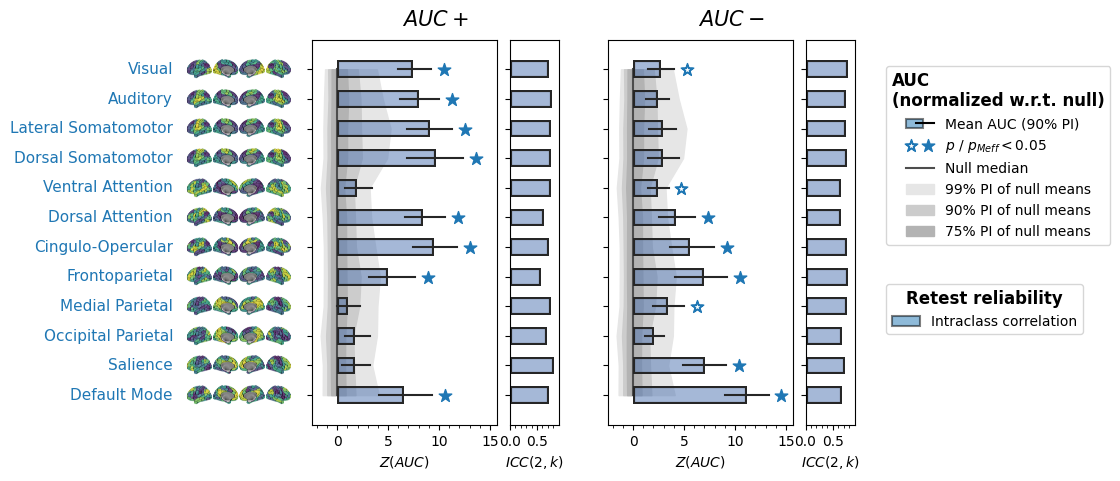

Schaefer400


In [21]:
measure = "pearson"
for parc in PARCS_CX:
    print(parc)
    
    plot_overview(
        parc, measure, "all", 
        save_path=wd / "plots" / "evaluate" / f"posctrloverview_parc-{parc}_measure-{measure}.pdf",
        plot_retest=True,
        stat="auc",
    )
    
    if parc in PARC_DEFAULT:
        plt.show()
    else:
        plt.close()